In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split


### Data cleaning & preprocessing

Before you modelling anything, we need to;

- Load and visually inpect our data  
- check for missing values and duplicate rows and handle them.

In [10]:
import pandas as pd
data = pd.read_csv('../data/marketing_and_sales_data_evaluate_lr.csv')

data = pd.DataFrame(data)
data.head()    


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [8]:
data.describe()

,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


In [ ]:
data.isnull().any() #checking for missing vals

TV              True
Radio           True
Social_Media    True
Sales           True
dtype: bool

In [ ]:
data.isna().sum()  

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

In [14]:
#handling missing values
data = data.dropna(subset=['TV', 'Radio', 'Social_Media', 'Sales'])

In [15]:
data.duplicated().any() # checking for duplicate rows

np.False_

## Exploratory Data Analysis

- check individual dist of each column

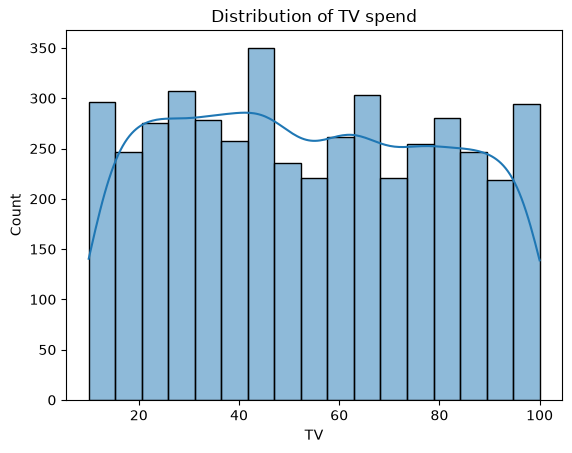

In [17]:
# distribution of TV spend

sb.histplot(data['TV'], kde=True)
plt.title('Distribution of TV spend')
plt.show()

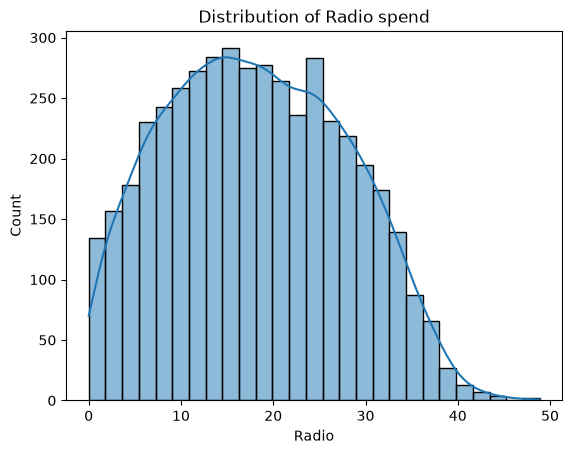

In [18]:
# distribution of Radio spend

sb.histplot(data['Radio'], kde=True)
plt.title('Distribution of Radio spend')
plt.show()

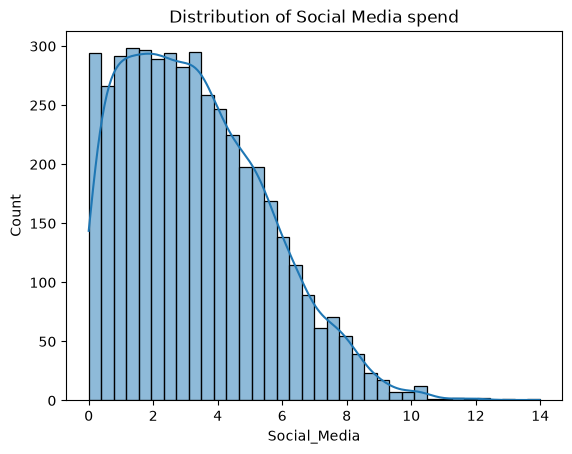

In [19]:
# distribution of Social media spend

sb.histplot(data['Social_Media'], kde=True)
plt.title('Distribution of Social Media spend')
plt.show()

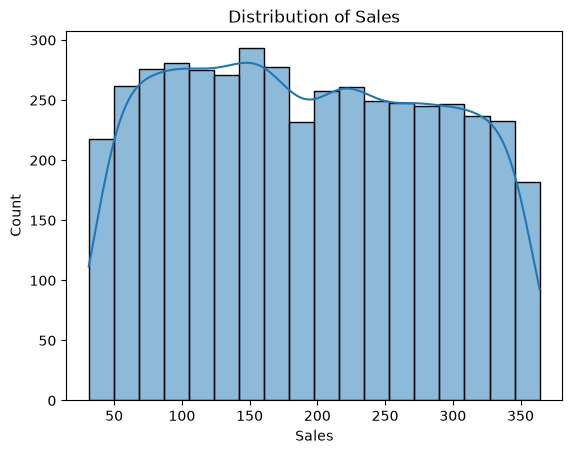

In [21]:
# distribution of sales

sb.histplot(data['Sales'], kde=True)
plt.title('Distribution of Sales')
plt.show()

### Relationships to Target (sales)

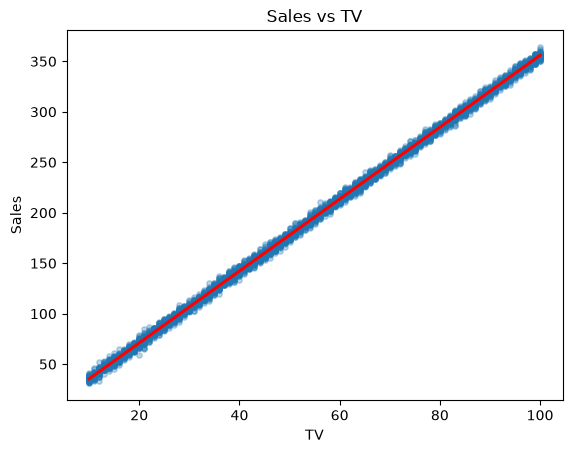

In [22]:
sb.regplot(x=data['TV'], y=data['Sales'], scatter_kws={'alpha': 0.3, 's': 15}, line_kws={'color': 'red'})
plt.title('Sales vs TV')
plt.show()

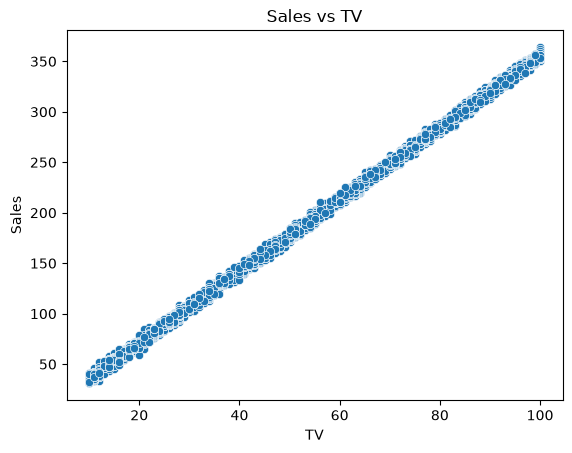

In [24]:
sb.scatterplot(x=data['TV'], y=data['Sales'])
plt.title('Sales vs TV')
plt.show()

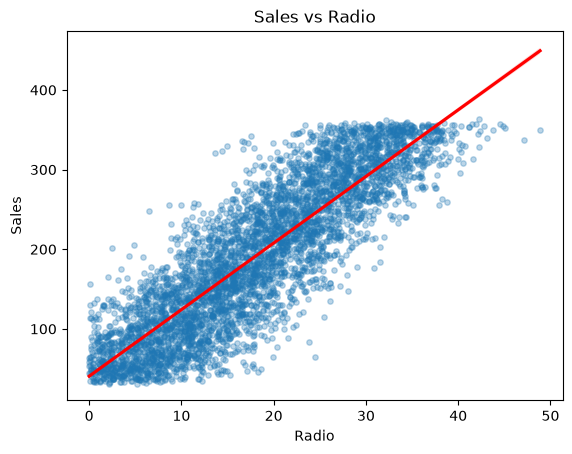

In [26]:
sb.regplot(x=data['Radio'], y=data['Sales'], scatter_kws={'alpha': 0.3, 's': 15}, line_kws={'color': 'red'})
plt.title('Sales vs Radio')
plt.show()

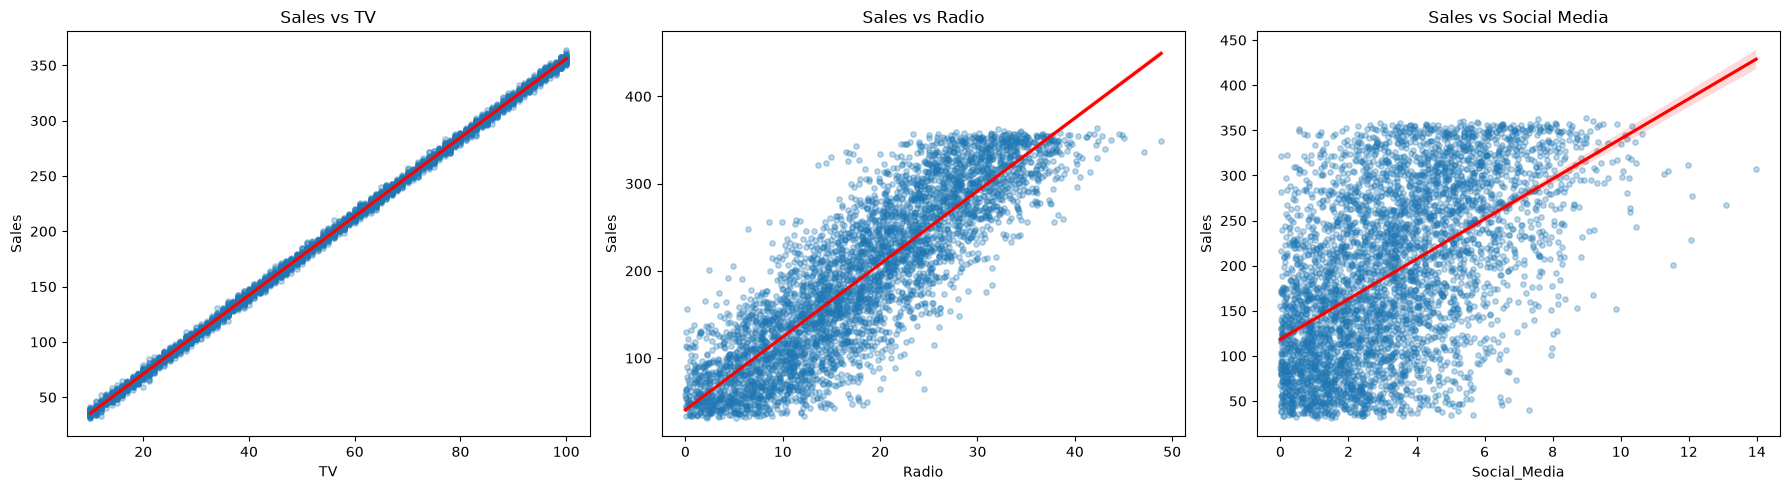

In [27]:


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# TV vs Sales
sb.regplot(
    x=data['TV'],
    y=data['Sales'],
    ax=axes[0],
    scatter_kws={'alpha': 0.3, 's': 15},
    line_kws={'color': 'red'}
)
axes[0].set_title('Sales vs TV')

# Radio vs Sales
sb.regplot(
    x=data['Radio'],
    y=data['Sales'],
    ax=axes[1],
    scatter_kws={'alpha': 0.3, 's': 15},
    line_kws={'color': 'red'}
)
axes[1].set_title('Sales vs Radio')

# Social Media vs Sales
sb.regplot(
    x=data['Social_Media'],
    y=data['Sales'],
    ax=axes[2],
    scatter_kws={'alpha': 0.3, 's': 15},
    line_kws={'color': 'red'}
)
axes[2].set_title('Sales vs Social Media')

plt.tight_layout()
plt.show()

### Correlation analysis

In [31]:
data.corr(method= 'pearson')

,TV,Radio,Social_Media,Sales
TV,1.000000,0.869158,0.527687,0.999497
Radio,0.869158,1.000000,0.606338,0.868638
Social_Media,0.527687,0.606338,1.000000,0.527446
Sales,0.999497,0.868638,0.527446,1.000000


<Axes: >

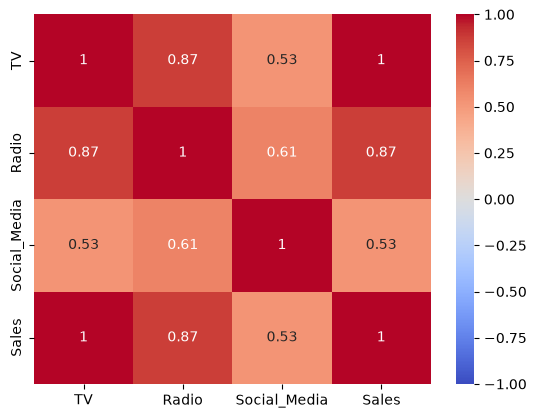

In [33]:
sb.heatmap(data[['TV','Radio','Social_Media','Sales']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)

In [29]:
corr_to_target = data[['TV', 'Radio', 'Social_Media']].corrwith(data['Sales'])
print(corr_to_target)

TV              0.999497
Radio           0.868638
Social_Media    0.527446
dtype: float64


In [35]:
best_feature = corr.abs().idxmax()   
best_feature

'TV'

### training the regression model 

In [40]:
#split data for training

x_train,x_test,y_train,y_test = train_test_split(data['TV'],data['Sales'], test_size=0.2,random_state=42)

In [42]:
import statsmodels.api as sm

X = x_train
X = sm.add_constant(X)   # adds a column for the intercept term
y = y_train

model = sm.OLS(y, X).fit()

In [43]:
model.params

const   -0.168966
TV       3.561912
dtype: float64

In [49]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 3.598e+06
Date:                Wed, 08 Jul 2026   Prob (F-statistic):               0.00
Time:                        19:54:56   Log-Likelihood:                -9110.9
No. Observations:                3636   AIC:                         1.823e+04
Df Residuals:                    3634   BIC:                         1.824e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1690      0.113     -1.500      0.1